### Import the important libraries of Python:-

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Now let us read the data:-

In [2]:
df = pd.read_csv("latest Covid-19 India Status1 (2).xls")

In [3]:
df

,State/UTs,Total Cases,Active,Deaths,Active Ratio (%),Death Ratio (%)
0,Maharashtra,6122893,117869,123857,1.93,2.02
1,Kerala,3011694,108400,14108,3.60,0.47
2,Karnataka,2862338,39626,35601,1.38,1.24
3,Tamil Nadu,2506848,34076,33196,1.36,1.32
4,Andhra Pradesh,1911231,32356,12919,1.69,0.68
5,Uttar Pradesh,1706934,1947,22666,0.11,1.33
6,West Bengal,1508223,16655,17850,1.10,1.18
7,Delhi,1434780,858,25005,0.06,1.74
8,Chhattisgarh,996689,5017,13464,0.50,1.35
9,Rajasthan,952887,935,8942,0.10,0.94


### Objectives:-

In [ ]:
# The objective of this project is to analyse COVID-19 data in India using Python and its libraries to 
# gain meaningful insights into the spread and impact of the virus across different states. The project 
# aims to :-
# 1) Examine total cases,active cases and deaths across various UTs/States.
# 2) Calculate and compare key matrices such as active ratio and death ratio.
# 3) Identify trends and patterns in Covid-19 data.
# 4) Highlight the most affected States and regions.
# 5) Support data driven understanding through visualisation and analysis.

### Data in brief:-

In [ ]:
#1) Column 'Active' represents the total active cases.
#2) Column 'Active ratio(%)' represents the value of '(Active/Total cases) * 100'.
#3) Column 'Death ratio(%)' represents the value of '(Deaths/Total cases) * 100'.

### Number of rows and colums:-

In [5]:
df.shape

(36, 6)

In [ ]:
# WE have 36 rows representing the total numbers of states and union terreteries.
# WE have 6 columns.

### Description of the dataframe:-

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State/UTs         36 non-null     object 
 1   Total Cases       36 non-null     int64  
 2   Active            36 non-null     int64  
 3   Deaths            36 non-null     int64  
 4   Active Ratio (%)  36 non-null     float64
 5   Death Ratio (%)   36 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.8+ KB


### Now let us check the missing values:-

In [9]:
df.isnull().sum(axis = 0)

State/UTs           0
Total Cases         0
Active              0
Deaths              0
Active Ratio (%)    0
Death Ratio (%)     0
dtype: int64

In [ ]:
# WE do not have any missing values.

#### Now let us simplify the columns names as pr our convenience:-

In [10]:
df.columns

Index(['State/UTs', 'Total Cases', 'Active', 'Deaths', 'Active Ratio (%)',
       'Death Ratio (%)'],
      dtype='object')

In [4]:
df.columns=['States', 'Total_Cases', 'Active', 'Deaths', 'Active_Ratio',
       'Death_Ratio']

In [5]:
df.head()

,States,Total_Cases,Active,Deaths,Active_Ratio,Death_Ratio
0,Maharashtra,6122893,117869,123857,1.93,2.02
1,Kerala,3011694,108400,14108,3.60,0.47
2,Karnataka,2862338,39626,35601,1.38,1.24
3,Tamil Nadu,2506848,34076,33196,1.36,1.32
4,Andhra Pradesh,1911231,32356,12919,1.69,0.68


### Display which of the following states have the maximum active ratio:-

In [16]:
df.head()

,States,Total_Cases,Active,Deaths,Active_Ratio,Death_Ratio
0,Maharashtra,6122893,117869,123857,1.93,2.02
1,Kerala,3011694,108400,14108,3.60,0.47
2,Karnataka,2862338,39626,35601,1.38,1.24
3,Tamil Nadu,2506848,34076,33196,1.36,1.32
4,Andhra Pradesh,1911231,32356,12919,1.69,0.68


In [20]:
df.sort_values(by='Active_Ratio',ascending=False).head(1)

,States,Total_Cases,Active,Deaths,Active_Ratio,Death_Ratio
30,Mizoram,22703,3960,100,17.44,0.44


#### Method 2:- 

In [29]:
df.groupby(['States'])['Active_Ratio'].max()

States
Andaman and Nicobar                          0.19
Andhra Pradesh                               1.69
Arunachal Pradesh                            8.78
Assam                                        4.46
Bihar                                        0.16
Chandigarh                                   0.16
Chhattisgarh                                 0.50
Dadra and Nagar Haveli and Daman and Diu     0.36
Delhi                                        0.06
Goa                                          1.16
Gujarat                                      0.24
Haryana                                      0.14
Himachal Pradesh                             0.66
Jammu and Kashmir                            1.08
Jharkhand                                    0.15
Karnataka                                    1.38
Kerala                                       3.60
Ladakh                                       0.91
Lakshadweep                                  2.47
Madhya Pradesh                             

In [32]:
df.groupby(['States'])['Active_Ratio'].max().sort_values(ascending=False).reset_index().head(1)

,States,Active_Ratio
0,Mizoram,17.44


### Let us plot a bar plot to represent the top ten states who has the most active ratio:-

In [12]:
d = df.sort_values(by='Active_Ratio',ascending=False).head(10)

In [13]:
d

,States,Total_Cases,Active,Deaths,Active_Ratio,Death_Ratio
30,Mizoram,22703,3960,100,17.44,0.44
31,Sikkim,21573,1975,311,9.15,1.44
24,Manipur,74341,6534,1229,8.79,1.65
28,Arunachal Pradesh,38283,3363,184,8.78,0.48
27,Meghalaya,52712,4229,886,8.02,1.68
25,Tripura,69019,4122,703,5.97,1.02
17,Assam,524556,23371,4743,4.46,0.90
29,Nagaland,25663,1070,505,4.17,1.97
1,Kerala,3011694,108400,14108,3.60,0.47
10,Odisha,929788,25148,4358,2.70,0.47


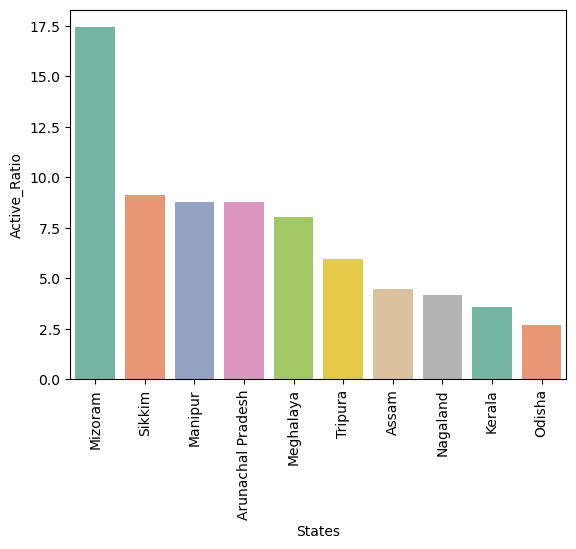

In [49]:
sns.barplot(x='States',y = 'Active_Ratio',data = d,palette = 'Set2')
plt.xticks(rotation = 90);

### Let us plot a bar plot to represent the top ten states who has the most death ratio:-

In [9]:
a = df.sort_values(by='Death_Ratio',ascending=False).head(10)

In [10]:
a

,States,Total_Cases,Active,Deaths,Active_Ratio,Death_Ratio
16,Punjab,596970,1964,16141,0.33,2.70
19,Uttarakhand,340959,1506,7338,0.44,2.15
0,Maharashtra,6122893,117869,123857,1.93,2.02
29,Nagaland,25663,1070,505,4.17,1.97
22,Goa,168015,1950,3082,1.16,1.83
7,Delhi,1434780,858,25005,0.06,1.74
21,Himachal Pradesh,203117,1338,3486,0.66,1.72
35,Andaman and Nicobar,7491,14,128,0.19,1.71
27,Meghalaya,52712,4229,886,8.02,1.68
24,Manipur,74341,6534,1229,8.79,1.65


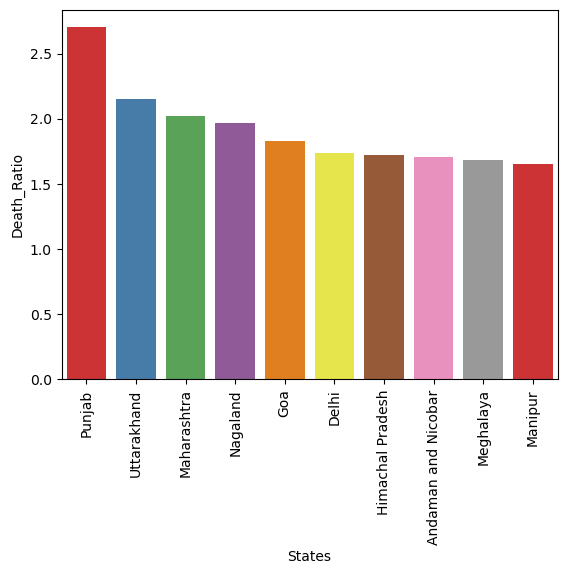

In [11]:
sns.barplot(x = 'States', y = 'Death_Ratio',palette ='Set1',data = a)
plt.xticks(rotation = 90);

### Now let us plot two pie charts representing the percentage of top ten active ratio and top ten death ratio:-

In [ ]:
# For this we will plot subplots two bar plots and two pie charts representing them in two rows and 
# two columns.

In [15]:
plt.figure(figsize=(10,15),dpi=1000)

# row-1, column-1:
plt.subplot(2,2,1)
plt.title('Top ten Active Cases states')
sns.barplot(x = 'States', y = 'Active_Ratio',data = d, palette = 'Set1')
plt.xticks(rotation = 90)

# row-1, column-2:
plt.subplot(2,2,2)
plt.title('Top ten Death Cases states')
sns.barplot(x = 'States', y = 'Death_Ratio', data = a, palette = 'Set1')
plt.xticks(rotation = 90)

# row-2, column-1:
plt.subplot(2,2,3)
plt.pie('Active_Ratio',labels = 'States', data = d,autopct = '%0.2f%%')

# row-2, column-2:
plt.subplot(2,2,4)
plt.pie('Death_Ratio',labels = 'States', data = a,autopct = '%0.2f%%');

### WE will compare the active cases and the total deaths:-

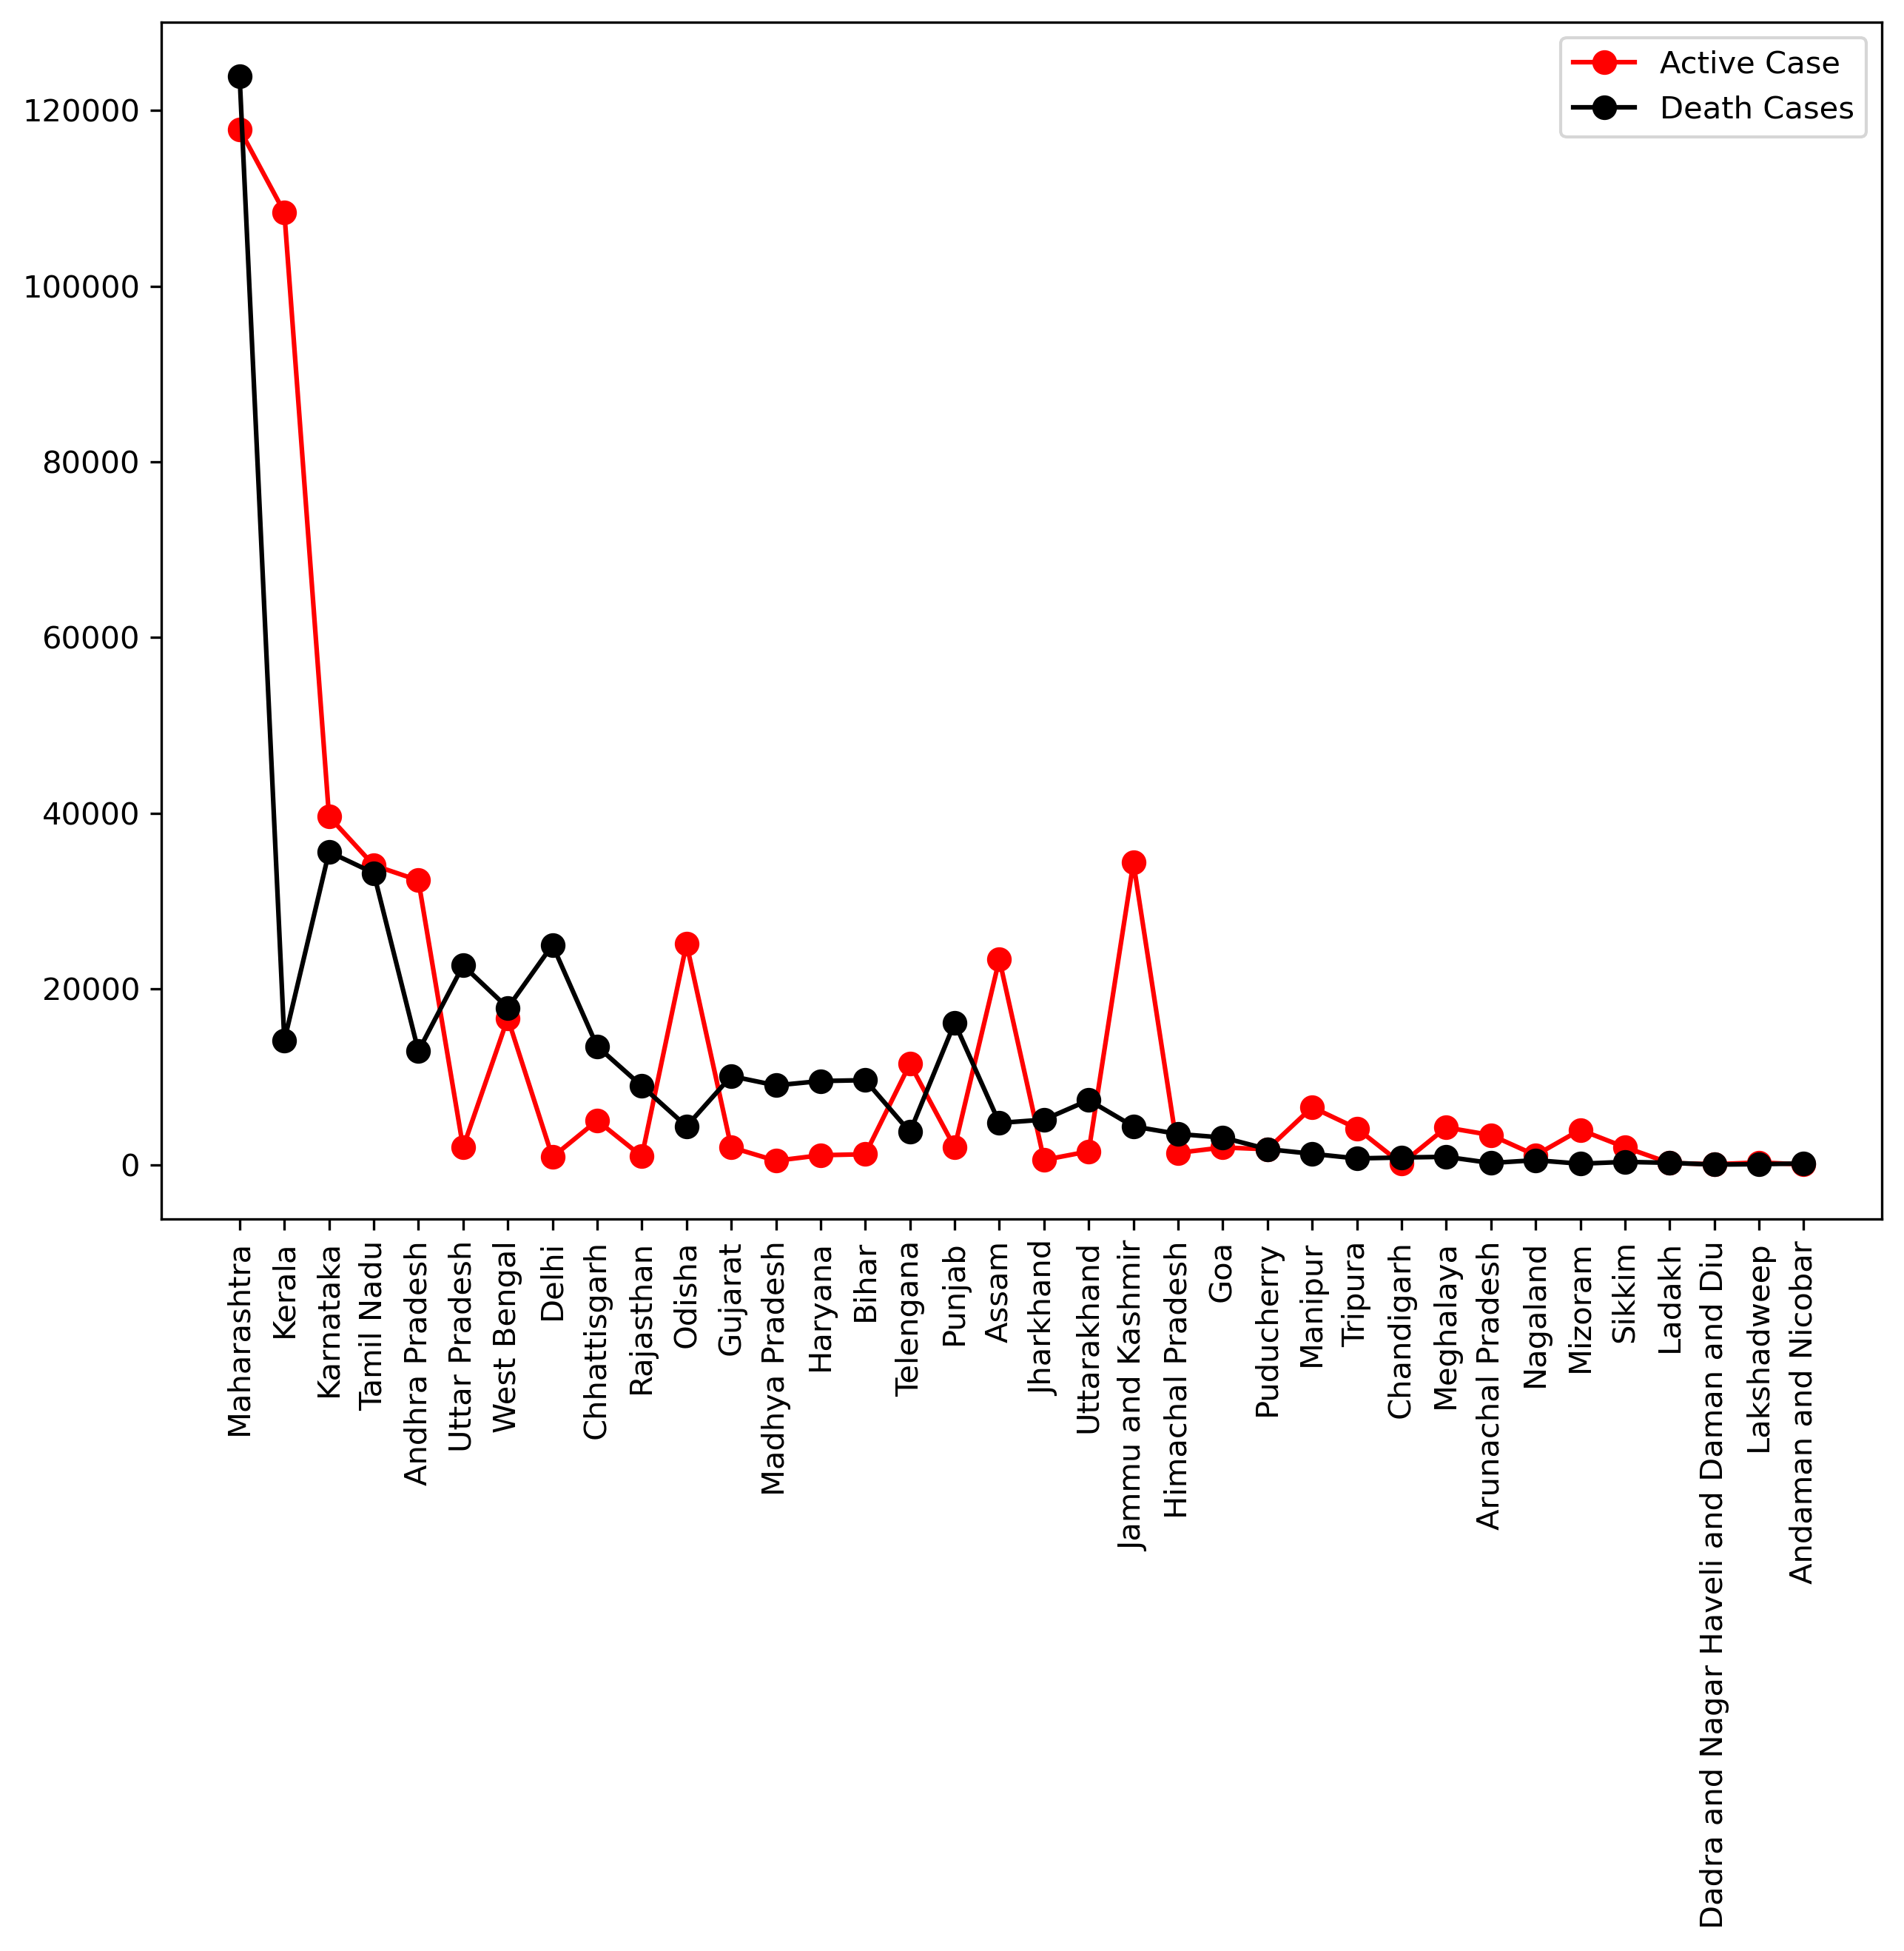

In [20]:
plt.figure(figsize=(10,7),dpi=300)
plt.plot(df['States'],df['Active'],color='red', marker='o',markersize=7,label='Active Case')
plt.plot(df['States'],df['Deaths'],color='k', marker='o',markersize=7,label='Death Cases')
plt.legend()
plt.xticks(rotation = 90);

In [ ]:
# Maharastra has the maximum numbers of death.

### More analysis in Data:-

In [ ]:
# In the data we we do not have the information regarding the recovered cases. So , we will analyse the 
# recovered cases in each states.

In [7]:
df['Recovered_Cases'] = df['Total_Cases']-(df['Active']+df['Deaths'])

In [8]:
df['Recovered_Ratio'] = df['Recovered_Cases']/df['Total_Cases']*100

In [9]:
df

,States,Total_Cases,Active,Deaths,Active_Ratio,Death_Ratio,Recovered_Cases,Recovered_Ratio
0,Maharashtra,6122893,117869,123857,1.93,2.02,5881167,96.052095
1,Kerala,3011694,108400,14108,3.60,0.47,2889186,95.932256
2,Karnataka,2862338,39626,35601,1.38,1.24,2787111,97.371834
3,Tamil Nadu,2506848,34076,33196,1.36,1.32,2439576,97.316471
4,Andhra Pradesh,1911231,32356,12919,1.69,0.68,1865956,97.631108
5,Uttar Pradesh,1706934,1947,22666,0.11,1.33,1682321,98.558058
6,West Bengal,1508223,16655,17850,1.10,1.18,1473718,97.712208
7,Delhi,1434780,858,25005,0.06,1.74,1408917,98.197424
8,Chhattisgarh,996689,5017,13464,0.50,1.35,978208,98.145761
9,Rajasthan,952887,935,8942,0.10,0.94,943010,98.963466


### The state with the maximum recovery ratio:-

In [13]:
df.sort_values(by='Recovered_Ratio',ascending = False).head(1)

,States,Total_Cases,Active,Deaths,Active_Ratio,Death_Ratio,Recovered_Cases,Recovered_Ratio
33,Dadra and Nagar Haveli and Daman and Diu,10576,38,4,0.36,0.04,10534,99.602874


### Top Ten states with the most numbers of recovered cases:-

In [14]:
a = df.sort_values(by='Recovered_Cases',ascending= False).head(10)

In [15]:
a

,States,Total_Cases,Active,Deaths,Active_Ratio,Death_Ratio,Recovered_Cases,Recovered_Ratio
0,Maharashtra,6122893,117869,123857,1.93,2.02,5881167,96.052095
1,Kerala,3011694,108400,14108,3.60,0.47,2889186,95.932256
2,Karnataka,2862338,39626,35601,1.38,1.24,2787111,97.371834
3,Tamil Nadu,2506848,34076,33196,1.36,1.32,2439576,97.316471
4,Andhra Pradesh,1911231,32356,12919,1.69,0.68,1865956,97.631108
5,Uttar Pradesh,1706934,1947,22666,0.11,1.33,1682321,98.558058
6,West Bengal,1508223,16655,17850,1.10,1.18,1473718,97.712208
7,Delhi,1434780,858,25005,0.06,1.74,1408917,98.197424
8,Chhattisgarh,996689,5017,13464,0.50,1.35,978208,98.145761
9,Rajasthan,952887,935,8942,0.10,0.94,943010,98.963466


### Bar plot for the top ten states with the most recovered caese:-

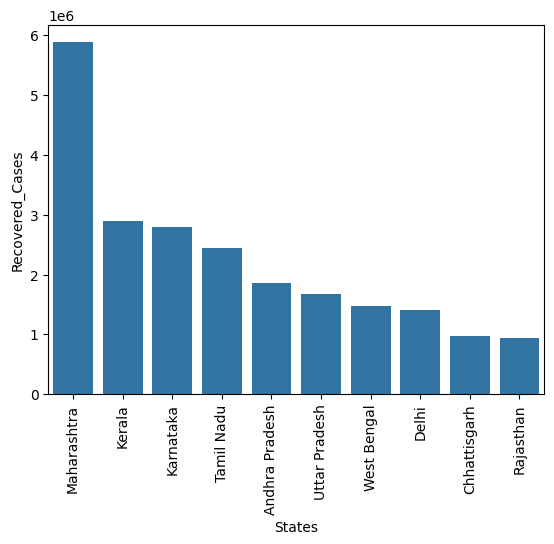

In [17]:
sns.barplot(x = 'States',y = 'Recovered_Cases', data = a)
plt.xticks(rotation = 90);
            

#### Note:- 'Le6' represents '10 to the power 6'.

### Comparison between 'Active ratio',death ratio' and recovered ratio':-

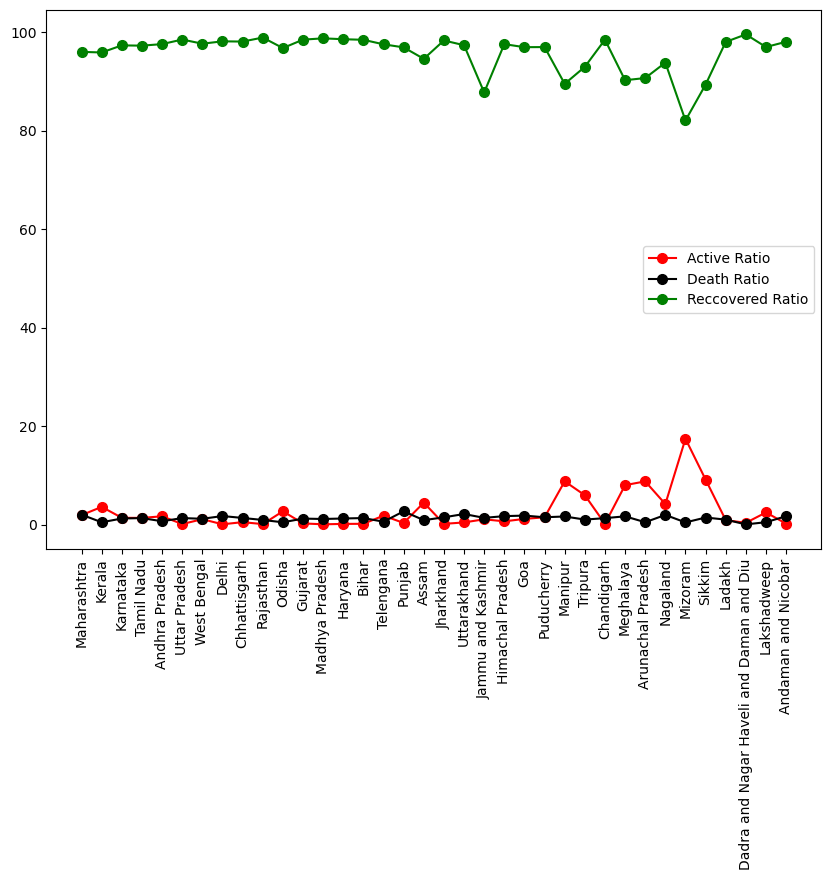

In [19]:
plt.figure(figsize=(10,7),dpi=100)
plt.plot(df['States'],df['Active_Ratio'],color='red', marker='o',markersize=7,label='Active Ratio')
plt.plot(df['States'],df['Death_Ratio'],color='k', marker='o',markersize=7,label='Death Ratio')
plt.plot(df['States'],df['Recovered_Ratio'],color='g', marker='o',markersize=7,label='Reccovered Ratio')
plt.legend()
plt.xticks(rotation = 90);

In [ ]:
# In the above plot the'Active ratio' or 'Death ratio' cannot be comapred with the 'Recovered ratio' as 
# the value of the recovered ratio is very high.

### Let us compare the active, death and recovered cases.

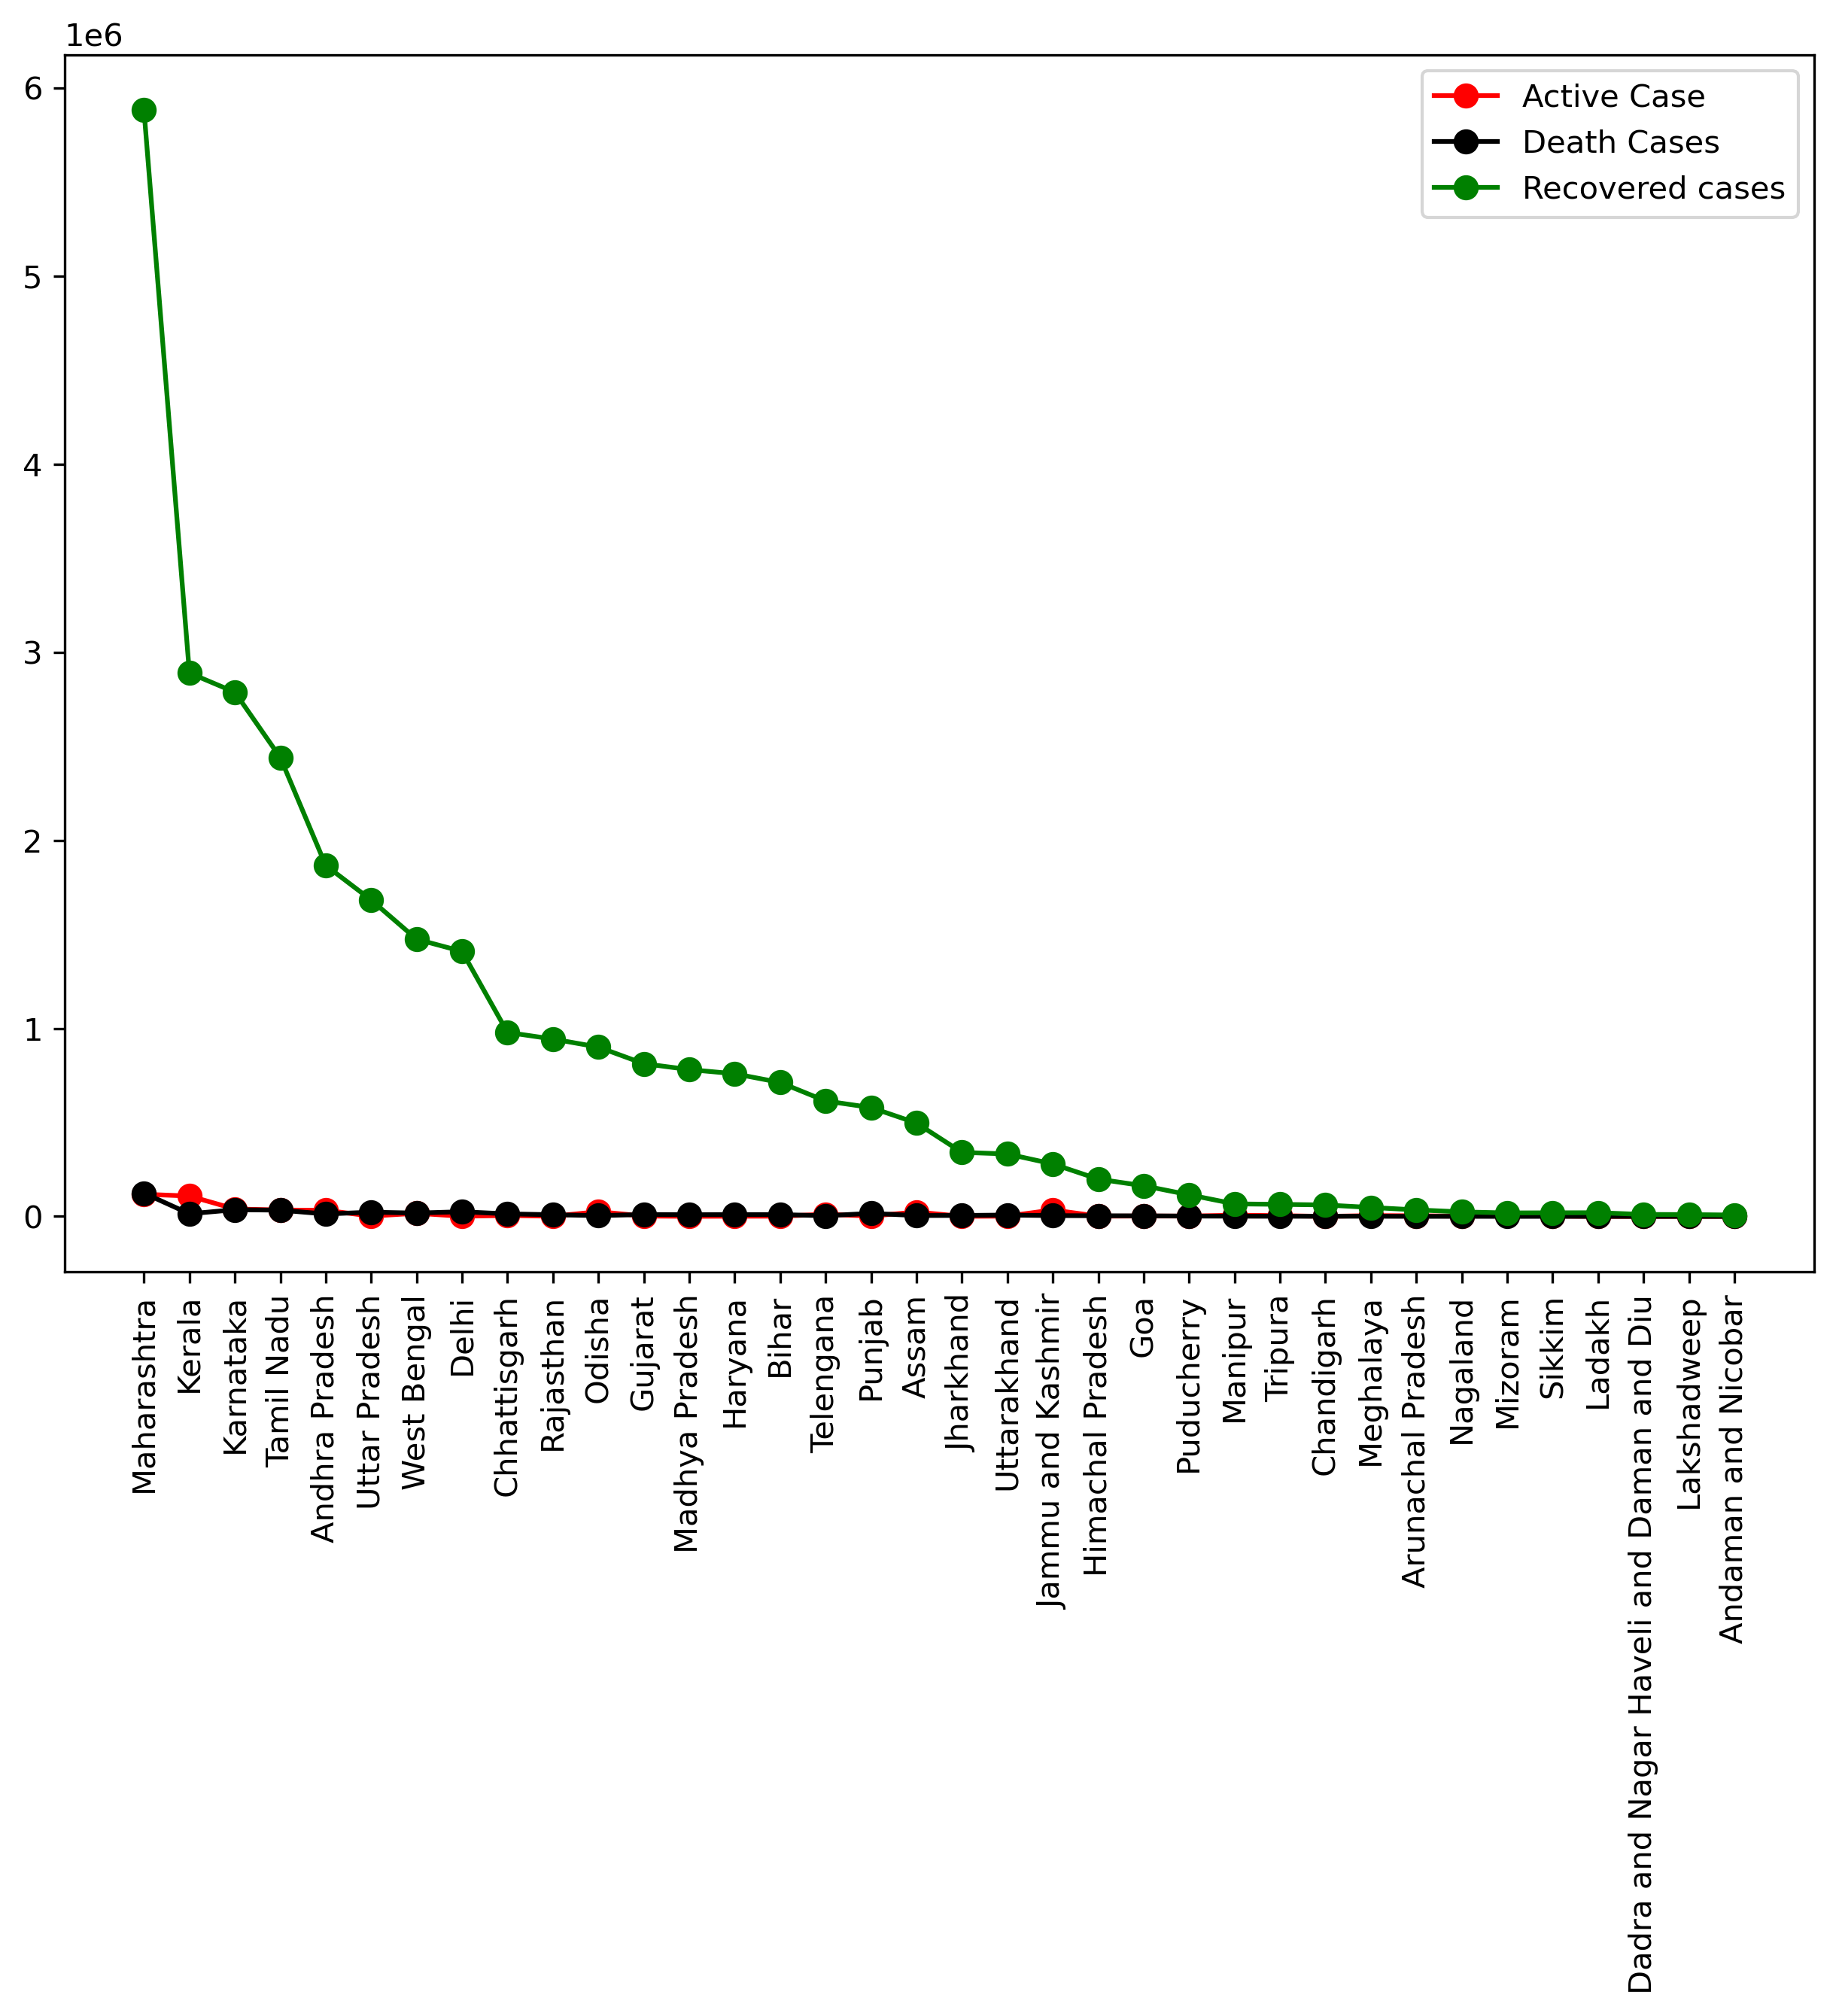

In [12]:
plt.figure(figsize=(10,7),dpi=300)
plt.plot(df['States'],df['Active'],color='red', marker='o',markersize=7,label='Active Case')
plt.plot(df['States'],df['Deaths'],color='k', marker='o',markersize=7,label='Death Cases')
plt.plot(df['States'],df['Recovered_Cases'],marker = 'o',color = 'g',markersize = 7,label = 'Recovered cases')
plt.legend()
plt.xticks(rotation = 90);

In [ ]:
# From the above plot it is clear that when the line plot was plotted only for 'death cases' and 'active
# cases' then we can see a lot of variation  in the graph. But when we  plotted the same for the 'active'
# 'death' and 'recovered cases' then aS the value for the recovered cases is very high all in '10**6',
# due to which the deviation of the scale got reduced. As a result the deviation in between the 'active'
# and 'death cases' got minimised beacuse initialy the line plot was judging their values in '10**4' while
# the deviation of the 'recovered cases' is clearly visible.

### Conclusion:-

In [ ]:
# The analysis of the COVID-19 data in India reveals significant variations in the impact of the 
# pandemic across different States. States like Maharashtra and Kerala reported higher total and active
# cases, indicating a grreater spread of the virus.
# The active ratio and death ratio helped in understanding the severity and the managment efficiency in
# different regions. Some states showed lower death ratios despite high case numbers, suggesting a better
# healthcare response.